In [52]:
import xarray as xr
import numpy as np
import rioxarray

In [ ]:
# 2008-2020 MetOp-A Data (constant orbit)
# seasonal trends and min and max
# day and night


In [5]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [ ]:
lst_2009 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2009/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [17]:
lst_2010 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2010/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [18]:
lst_2011 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2011/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [34]:
lst_2012 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2012/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [19]:
lst_2013 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2013/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [20]:
lst_2014 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2014/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [21]:
lst_2015 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2015/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [22]:
lst_2016 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2016/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [23]:
lst_2017 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2017/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [24]:
lst_2018 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2018/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [25]:
lst_2019 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2019/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [26]:
lst_2020 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2020/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

In [ ]:
# load water mask in the end !

In [58]:
lst_2020

<xarray.Dataset> Size: 101GB
Dimensions:      (lat: 800, lon: 7200, time: 366)
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time         (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon, time) float64 17GB dask.array<chunksize=(800, 7200, 1), meta=np.ndarray>
    satzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    sunzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    scan_time    (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    test_mae     (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    r2           (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>

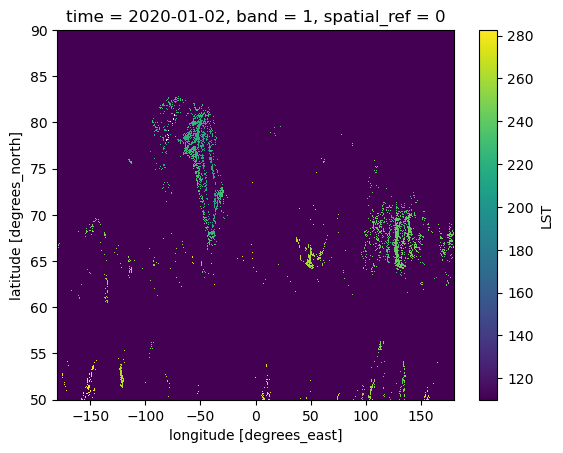

In [63]:
lst_2020['LST'].isel(time=1).plot();

In [64]:
# load the time series somewhere ?
results = {}

for year in range(2008, 2021):

    ds = globals()[f"lst_{year}"]   # load lst_1981, lst_1982, ...

    clean_LST = ds['LST'].where(ds['LST'] > 110, np.nan)
    monthly_mean = (
        clean_LST
        .resample(
            time='1MS'
        )
        .mean()
    )

    # Ensure bins exist even with no data
    # Xarray automatically creates them and fills with NaN

    results[year] = monthly_mean

combined = xr.concat([results[y] for y in range(2008, 2021)], dim="time")

In [65]:
combined

<xarray.DataArray 'LST' (lat: 800, lon: 7200, time: 156)> Size: 7GB
dask.array<concatenate, shape=(800, 7200, 156), dtype=float64, chunksize=(800, 7200, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 1kB 2008-01-01 2008-02-01 ... 2020-12-01

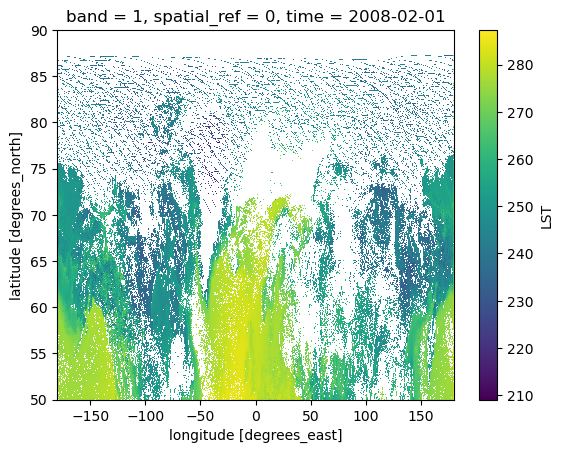

In [66]:
combined.isel(time=1).plot();

In [67]:
climatology = combined.groupby('time.season').mean("time")

In [68]:
min = combined.groupby('time.season').min("time")

In [69]:
max = combined.groupby('time.season').max("time")

In [70]:
min

<xarray.DataArray 'LST' (lat: 800, lon: 7200, season: 4)> Size: 184MB
dask.array<transpose, shape=(800, 7200, 4), dtype=float64, chunksize=(800, 7200, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [71]:
water_mask = rioxarray.open_rasterio('/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif')
water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))

water_mask_crop = water_mask.sel(lat=slice(50,90))
water_mask_true = combined.isel(time=0).copy(data=np.array(np.squeeze(water_mask_crop)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)

In [72]:
clim_masked = climatology * ls_mask

In [78]:
min_masked = min * ls_mask

In [79]:
max_masked = max * ls_mask

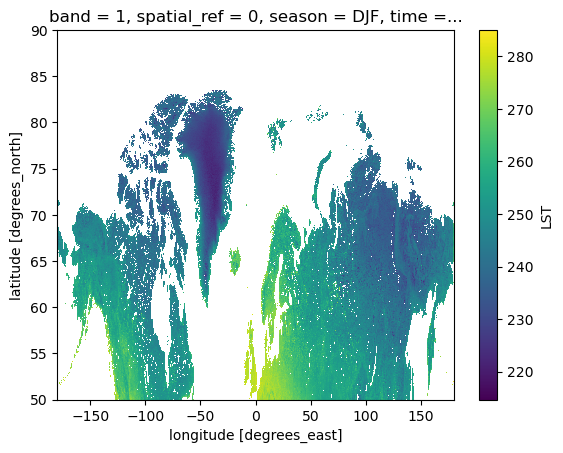

In [73]:
# remove water !!! from water mask -> and do nice subplots
clim_masked.sel(season='DJF').plot();

In [75]:
clim_loaded = clim_masked.load()

In [80]:
min_loaded = min_masked.load()

In [81]:
max_loaded = max_masked.load()

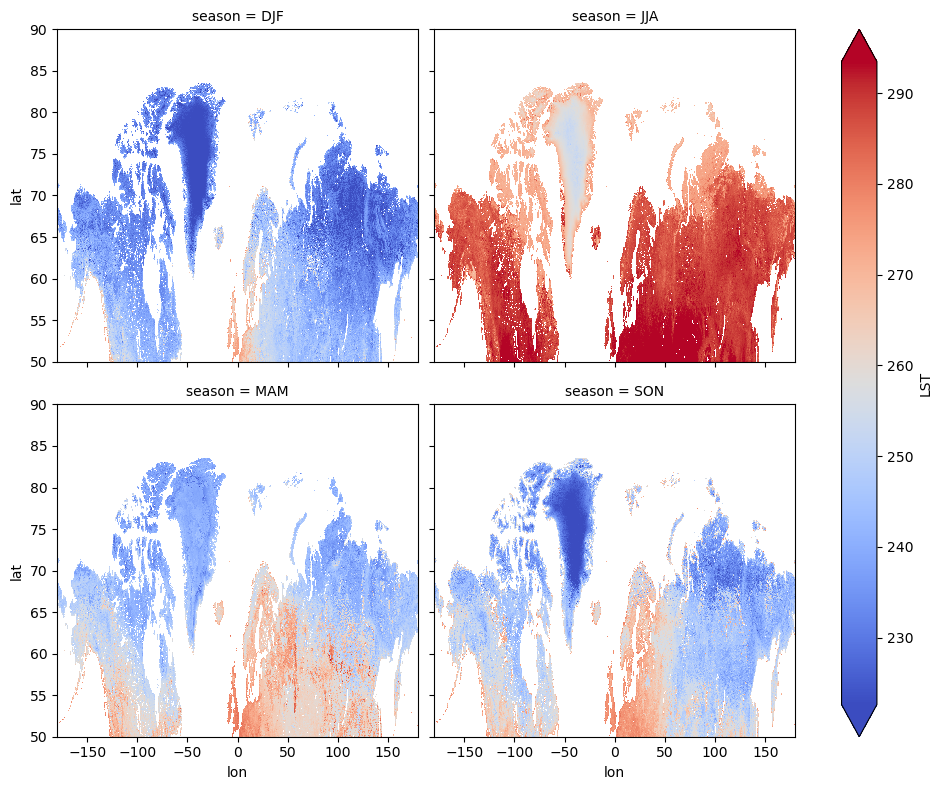

In [83]:
min_loaded.plot(
    col='season',
    col_wrap=2,
    cmap='coolwarm',
    robust=True,   # avoids outliers dominating color scale
    figsize=(10, 8)
)
plt.savefig('min_temp_2008_2020.png')

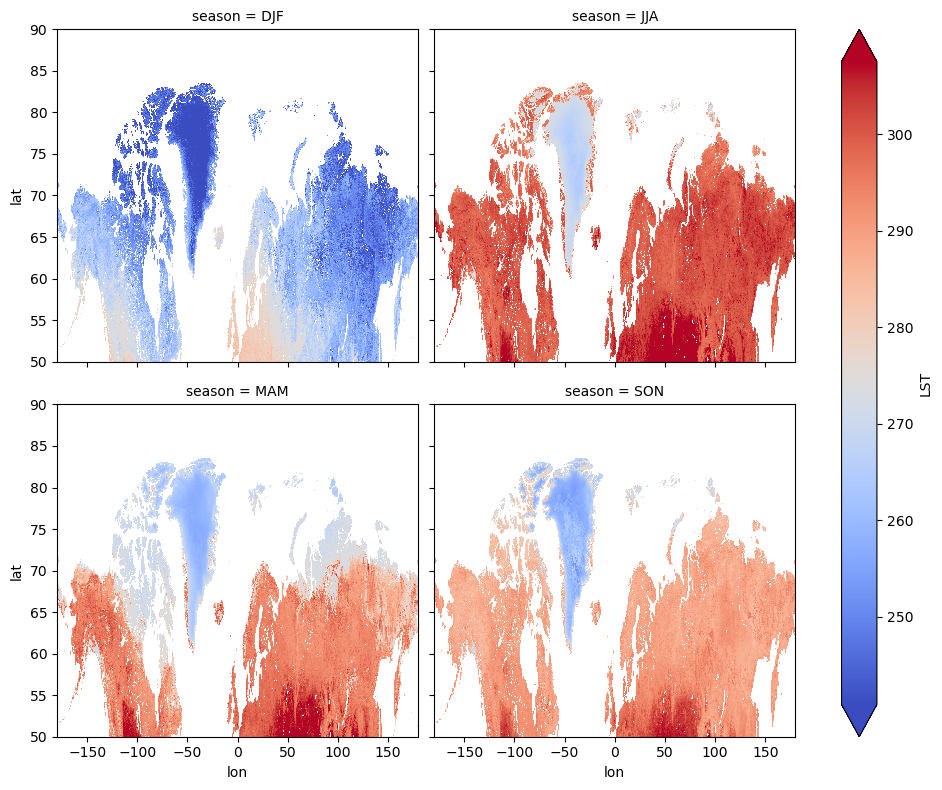

In [82]:
max_loaded.plot(
    col='season',
    col_wrap=2,
    cmap='coolwarm',
    robust=True,   # avoids outliers dominating color scale
    figsize=(10, 8)
)
plt.savefig('max_temp_2008_2020.png')

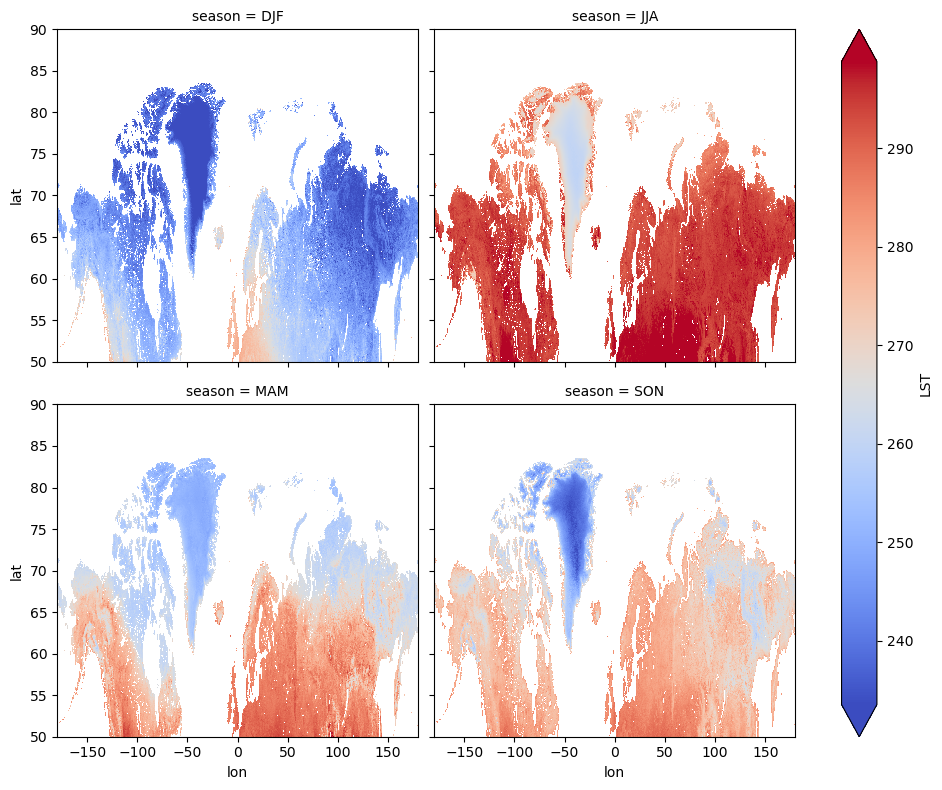

In [77]:
clim_loaded.plot(
    col='season',
    col_wrap=2,
    cmap='coolwarm',
    robust=True,   # avoids outliers dominating color scale
    figsize=(10, 8)
)
plt.savefig('mean_temp_2008_2020.png')

KeyboardInterrupt: 

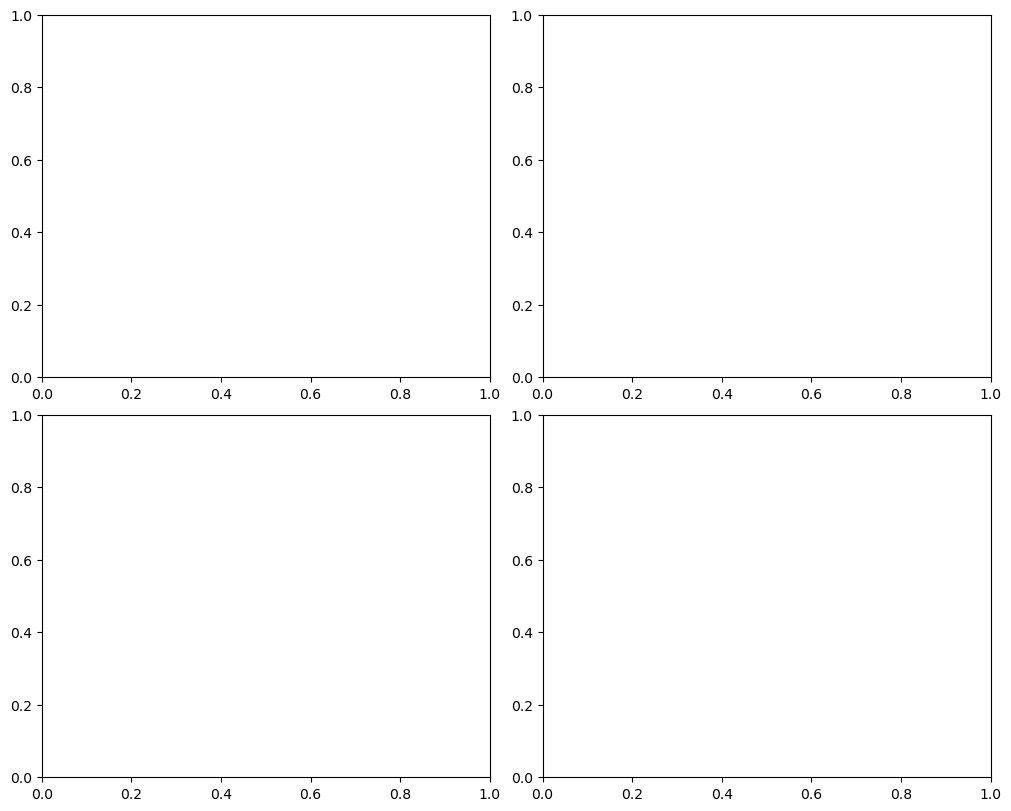

In [74]:
import matplotlib.pyplot as plt

# Ensure consistent color scale across all seasons
vmin = clim_masked.min()
vmax = clim_masked.max()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

seasons = ['DJF', 'MAM', 'JJA', 'SON']

for ax, season in zip(axes.flat, seasons):
    im = clim_masked.sel(season=season).plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm',   # or 'RdBu_r' for temperature
        add_colorbar=False
    )
    ax.set_title(season)

# Add ONE shared colorbar
cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8)
cbar.set_label('Temperature [K]')  # adjust unit if needed

plt.show()

In [ ]:
# do min and max
